# DSS Availability - Monthly Progression

Author: Erick Chauke

Date: May 2026

This notebook turns the monthly availability workbook into one slide-ready chart: each service's monthly availability from April to the latest month, with year-to-date shown alongside. Per-service targets differ and are deliberately left off the chart. It is built section by section, run in VS Code one cell at a time.

## Setup and config

Everything downstream reads from the single config cell below. To point this notebook at a different workbook, change only that cell and run all. The cell after it loads the libraries and resolves the paths.

In [7]:
# CONFIG - the only cell you edit to point at a different dataset
DATA_FILE = "data/availability.xlsx"   # source workbook (gitignored)
YEAR_SHEET = None                       # fiscal-year sheet to chart; None = latest sheet
OUTPUT_DIR = "outputs"                  # where the slide image is saved
Y_AXIS_PAD = 0.5                        # percentage points of headroom around the data range


In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_PATH = Path(DATA_FILE)
OUT_PATH = Path(OUTPUT_DIR)
OUT_PATH.mkdir(exist_ok=True)
STEM = DATA_PATH.stem

print("pandas", pd.__version__)
print("data file:", DATA_PATH, "| exists:", DATA_PATH.exists())
print("output dir:", OUT_PATH.resolve())


pandas 2.2.3
data file: data\availability.xlsx | exists: True
output dir: D:\2026\Eskom\DSS availability\availability-visualiser\outputs


## Data ingestion and inspection

The workbook holds one sheet per fiscal year plus a couple of helper sheets. This section discovers the fiscal-year sheets, selects the one to chart (the config value, or the latest year by default), and reads it with no assumed header so we can locate the summary and history blocks ourselves. The raw frame is printed so the real layout is confirmed before any parsing.

In [9]:
import re

xl = pd.ExcelFile(DATA_PATH)

def fiscal_year_start(name):
    m = re.match(r"(\d{4})-\d{4}", name)
    return int(m.group(1)) if m else None

year_sheets = sorted(
    [s for s in xl.sheet_names if fiscal_year_start(s) is not None],
    key=fiscal_year_start,
)
sheet = YEAR_SHEET or year_sheets[-1]

print("all sheets   :", xl.sheet_names)
print("year sheets  :", year_sheets)
print("charting     :", sheet)

raw = pd.read_excel(DATA_PATH, sheet_name=sheet, header=None, na_values=["NULL", "None"])
print("raw shape    :", raw.shape)
print("current month:", raw.iloc[0, 1])
raw


all sheets   : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027', 'Sheet1']
year sheets  : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027']
charting     : 2026-2027
raw shape    : (26, 13)
current month: May


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Month,May,NaN,NaN,NaN,NaN,<--- Change this to get a report for the speci...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Service,Availability,YTD,Target,Comment,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Powi,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Systemops,0.99998,0.99997,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Themis,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,TEMSE HIS,1,0.99999,0.99,NaN,"""http://ncssnagios.eskom.co.za/trends.html""",NaN,NaN,NaN,""" with user/passwod: nagiosadmin""",NaN,NaN
6,NaN,TEMSE NCC,0.99995,0.999955,0.99992,NaN,"""http://systemops.eskom.co.za/temse/downtime/""",NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,TEMSE SCC,0.9993,0.9993,0.9992,NaN,"""SCC availability link on http://encweb1e06"" -...",NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Powi,Powi YTD,Systemops,Systemops YTD,Themis,Themis YTD,TEMSE HIS,HIS YTD,TEMSE NCC,NCC YTD,TEMSE SCC,SCC YTD


## Cleaning and parsing

The history block sits below the summary block in each sheet. We anchor on the April and March month labels to locate it without hard-coding row numbers, pair each service column with the YTD column immediately to its right, and reshape into a tidy long table with one row per service and month. Availability is stored as a fraction in the workbook, so we scale it to a percentage. Numeric coercion is logged. Months with no reading yet (the future months of the current year) are dropped from the monthly series, while the YTD carried in the workbook gives each service its year-to-date figure.

In [10]:
# Locate the history block by anchoring on the April and March month labels
month_labels = raw[0].astype(str).str.strip()
april_idx = month_labels[month_labels == "April"].index[0]
march_idx = month_labels[month_labels == "March"].index[0]
header = raw.iloc[april_idx - 1]

# Pair each service column with the YTD column immediately to its right
service_cols = {}
c = 1
while c < raw.shape[1] and pd.notna(header[c]):
    service_cols[str(header[c]).strip()] = (c, c + 1)
    c += 2

SERVICES = list(service_cols)
print("services:", SERVICES)

# Reshape the month rows into tidy long form, scaling fractions to percentages
hist = raw.iloc[april_idx:march_idx + 1]
months = hist[0].astype(str).str.strip().tolist()

records = []
lost = 0
for svc, (avail_c, ytd_c) in service_cols.items():
    avail = pd.to_numeric(hist[avail_c], errors="coerce")
    ytd = pd.to_numeric(hist[ytd_c], errors="coerce")
    lost += int((avail.isna() & hist[avail_c].notna()).sum())
    lost += int((ytd.isna() & hist[ytd_c].notna()).sum())
    for m, a, y in zip(months, avail, ytd):
        records.append({
            "service": svc,
            "month": m,
            "availability": a * 100 if pd.notna(a) else a,
            "ytd": y * 100 if pd.notna(y) else y,
        })

tidy = pd.DataFrame(records)
tidy["month"] = pd.Categorical(tidy["month"], categories=months, ordered=True)
print("values lost to coercion:", lost)

# Monthly series keeps only months with a real reading; YTD reference is the latest one
monthly = tidy.dropna(subset=["availability"]).copy()
filled_months = monthly["month"].cat.remove_unused_categories().cat.categories.tolist()
latest_month = filled_months[-1]
ytd_now = tidy[tidy["month"] == latest_month].set_index("service")["ytd"]

print("filled months:", filled_months)
print("latest month :", latest_month)
print()
print("current year to date by service:")
print(ytd_now.to_string())
monthly


services: ['Powi', 'Systemops', 'Themis', 'TEMSE HIS', 'TEMSE NCC', 'TEMSE SCC']
values lost to coercion: 0
filled months: ['April', 'May']
latest month : May

current year to date by service:
service
Powi         100.0000
Systemops     99.9970
Themis       100.0000
TEMSE HIS     99.9990
TEMSE NCC     99.9955
TEMSE SCC     99.9300


,service,month,availability,ytd
0,Powi,April,100.000,100.0000
1,Powi,May,100.000,100.0000
12,Systemops,April,99.996,99.9960
13,Systemops,May,99.998,99.9970
24,Themis,April,100.000,100.0000
25,Themis,May,100.000,100.0000
36,TEMSE HIS,April,99.998,99.9980
37,TEMSE HIS,May,100.000,99.9990
48,TEMSE NCC,April,99.996,99.9960
49,TEMSE NCC,May,99.995,99.9955


## Visualisation

One figure, laid out as an executive tile grid with a small panel per service, sized for a single slide. Each tile shows that service's monthly availability as a solid blue line and its year to date as an orange dashed line across the months from April to the latest, so a weak month shows up as a dip instead of being averaged away. The lowest monthly point is marked in red and its value printed, the current month and year to date are called out in the top corners, and a footer summarises the worst dip and the lowest results across all services.

Three deliberate choices follow the report owner's guidance. Tiles are ordered by the current month value, lowest first, so the services worth attention lead and the steady 100 percent ones come last. The vertical axis never goes above 100 percent, and each tile scales its own lower bound so a small dip stays visible. Nothing is hard coded for a given month: the latest sheet and the latest filled month are detected from the workbook, so re-running on next month's file just works. Per-service targets are left off. The figure is saved to the outputs folder under a name that carries the source file stem.

saved outputs\availability_monthly_availability.png


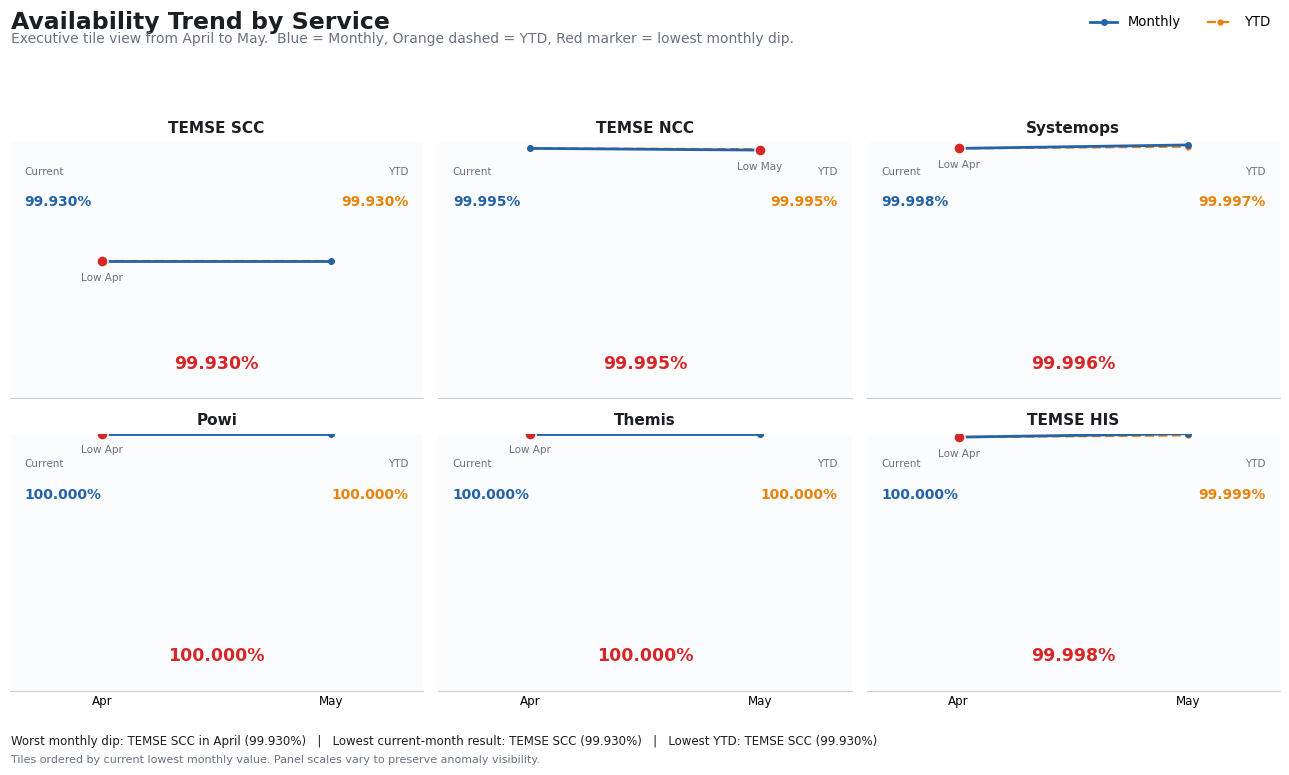

In [11]:
import math

# Palette
MONTH_C = "#2563a8"   # monthly availability
YTD_C = "#e8830c"     # year to date
DIP_C = "#d62728"     # lowest monthly dip
INK = "#1b1f24"
MUTED = "#6b7280"
PANEL_BG = "#fbfcfe"

# Per-service series over the filled months, plus the facts each tile calls out
data = {}
for svc in SERVICES:
    s = monthly[monthly["service"] == svc].set_index("month")
    yv = tidy[tidy["service"] == svc].set_index("month")
    mvals = [s.loc[m, "availability"] if m in s.index else None for m in filled_months]
    yvals = [yv.loc[m, "ytd"] if (m in yv.index and pd.notna(yv.loc[m, "ytd"])) else None
             for m in filled_months]
    clean = [v for v in mvals if v is not None]
    low = min(clean)
    low_i = mvals.index(low)
    data[svc] = dict(mvals=mvals, yvals=yvals, low=low, low_i=low_i,
                     current=clean[-1], ytd=[v for v in yvals if v is not None][-1])

# Order tiles by current month value, lowest (most interesting) first
order = sorted(SERVICES, key=lambda s: data[s]["current"])

# Footer facts across all services
worst = min(SERVICES, key=lambda s: data[s]["low"])
low_cur = min(SERVICES, key=lambda s: data[s]["current"])
low_ytd = min(SERVICES, key=lambda s: data[s]["ytd"])

n = len(filled_months)
ncols = 3
nrows = math.ceil(len(SERVICES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 7.2))
fig.patch.set_facecolor("white")
axes = axes.ravel()

x = list(range(n))
if n > 6:
    show_ticks = list(range(0, n, 2))
    if (n - 1) not in show_ticks:
        show_ticks.append(n - 1)
else:
    show_ticks = x

for pos, (ax, svc) in enumerate(zip(axes, order)):
    d = data[svc]
    ax.set_facecolor(PANEL_BG)
    row = pos // ncols

    ax.plot(x, d["yvals"], color=YTD_C, linestyle=(0, (4, 2)), linewidth=1.6,
            marker="o", markersize=3.5, zorder=3)
    ax.plot(x, d["mvals"], color=MONTH_C, linewidth=2.0, marker="o", markersize=4, zorder=4)
    ax.plot([x[d["low_i"]]], [d["low"]], "o", color=DIP_C, markersize=8, zorder=6,
            markeredgecolor="white", markeredgewidth=1.0)

    # vertical scale: never above 100, open downward enough to show the dip
    panel_min = min([v for v in d["mvals"] + d["yvals"] if v is not None])
    ymin = panel_min - ((100 - panel_min) * 0.25 + 0.02)
    if 100 - ymin < 0.15:
        ymin = 100 - 0.15
    ax.set_ylim(ymin, 100)
    ax.set_xlim(-0.4, n - 0.6)

    ax.text(0.035, 0.9, "Current", transform=ax.transAxes, fontsize=7.5, color=MUTED, va="top")
    ax.text(0.035, 0.79, f"{d['current']:.3f}%", transform=ax.transAxes, fontsize=10,
            fontweight="bold", color=MONTH_C, va="top")
    ax.text(0.965, 0.9, "YTD", transform=ax.transAxes, fontsize=7.5, color=MUTED, va="top", ha="right")
    ax.text(0.965, 0.79, f"{d['ytd']:.3f}%", transform=ax.transAxes, fontsize=10,
            fontweight="bold", color=YTD_C, va="top", ha="right")
    ax.annotate(f"Low {str(filled_months[d['low_i']])[:3]}", (x[d["low_i"]], d["low"]),
                textcoords="offset points", xytext=(0, -14), ha="center", fontsize=7.5, color=MUTED)
    ax.text(0.5, 0.1, f"{d['low']:.3f}%", transform=ax.transAxes, fontsize=12.5,
            fontweight="bold", color=DIP_C, ha="center", va="bottom")

    ax.set_title(svc, fontsize=11, fontweight="bold", color=INK)
    ax.set_yticks([])
    ax.grid(axis="y", color="#e9edf2", linewidth=0.8, zorder=0)
    ax.set_xticks([x[i] for i in show_ticks])
    if row == nrows - 1:
        ax.set_xticklabels([str(filled_months[i])[:3] for i in show_ticks], fontsize=8.5)
    else:
        ax.set_xticklabels([])
    ax.tick_params(length=0)
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color("#c8ccd1")

for ax in axes[len(SERVICES):]:
    ax.set_visible(False)

fig.suptitle("Availability Trend by Service", x=0.012, y=1.01, ha="left",
             fontsize=17, fontweight="bold", color=INK)
fig.text(0.012, 0.965,
         f"Executive tile view from April to {latest_month}.  "
         f"Blue = Monthly, Orange dashed = YTD, Red marker = lowest monthly dip.",
         ha="left", fontsize=10, color=MUTED)

handles = [
    plt.Line2D([], [], color=MONTH_C, marker="o", linewidth=2.0, markersize=4, label="Monthly"),
    plt.Line2D([], [], color=YTD_C, linestyle=(0, (4, 2)), marker="o", markersize=3.5,
               linewidth=1.6, label="YTD"),
]
fig.legend(handles=handles, loc="upper right", ncol=2, frameon=False, fontsize=9.5,
           bbox_to_anchor=(0.99, 1.02))

fig.text(0.012, -0.01,
         f"Worst monthly dip: {worst} in {str(filled_months[data[worst]['low_i']])} "
         f"({data[worst]['low']:.3f}%)   |   "
         f"Lowest current-month result: {low_cur} ({data[low_cur]['current']:.3f}%)   |   "
         f"Lowest YTD: {low_ytd} ({data[low_ytd]['ytd']:.3f}%)",
         ha="left", fontsize=8.5, color=INK)
fig.text(0.012, -0.035,
         "Tiles ordered by current lowest monthly value. Panel scales vary to preserve anomaly visibility.",
         ha="left", fontsize=8, color=MUTED)

fig.tight_layout(rect=[0.0, 0.02, 1, 0.93])
fig_path = OUT_PATH / f"{STEM}_monthly_availability.png"
fig.savefig(fig_path, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path)
plt.show()


### What the tile view shows

The tiles are ordered so the services that need attention come first. For the current year through May, TEMSE SCC leads because it sits lowest at 99.930 percent, followed by TEMSE NCC and Systemops a hair below 100, while Powi, Themis and TEMSE HIS sit on 100 and fall to the end. Every tile is flat so far, which is the good news: no service has had an off month yet, and in each tile the monthly line and the year-to-date line track together. The design earns its keep as the year fills out. The lowest monthly point in each tile is already marked in red, so the first time a service has a weak month that marker will drop away from the top of its tile and the footer will name it. Because each tile scales its own axis up to a ceiling of 100 percent, a small dip is not flattened out and nothing is ever drawn above 100.

## Alternative view: grouped columns

A second take on the same data for comparison, so the chart style can be chosen on its merits. Services sit along the bottom; within each service a column is drawn for every month from April to the latest, the value is printed on each column because the services run so close together, and the red diamond marks the year to date. It reads cleanly for a few months and gets busier as the year fills out. This figure is saved to the outputs folder under its own name so it does not overwrite the panel view.

saved outputs\availability_monthly_availability_columns.png


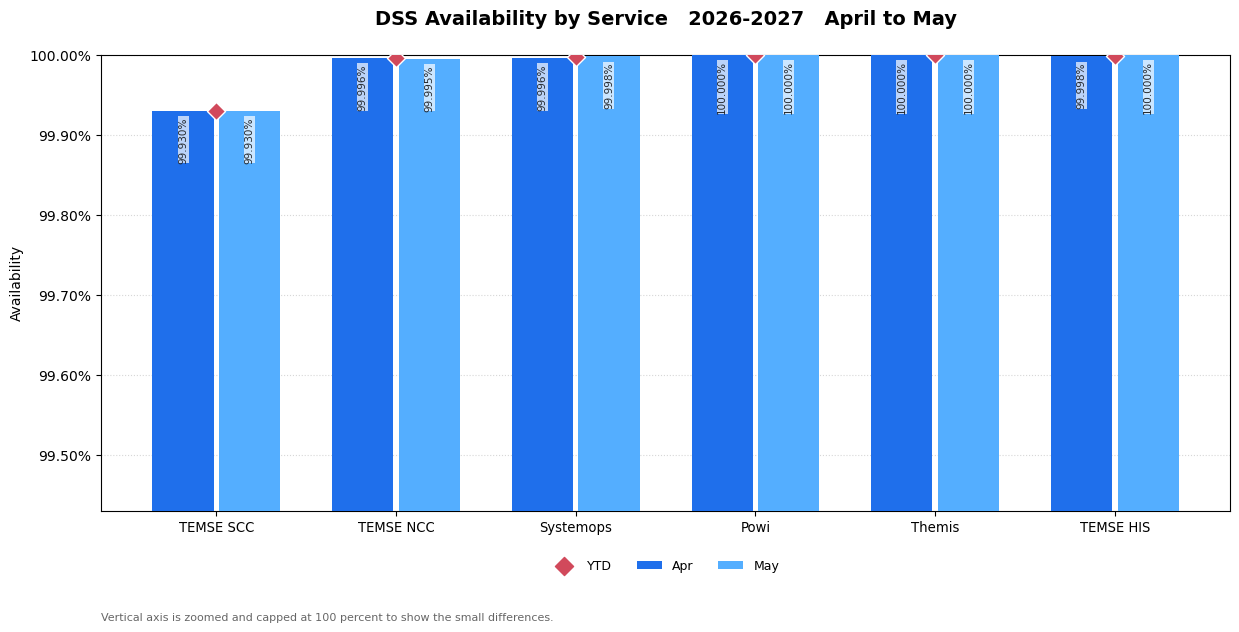

In [12]:
# Months in shades of blue, year to date as a red diamond. Services follow the tile order.
COL_MONTH_COLORS = ["#1f6feb", "#54aeff", "#a5d6ff"]
COL_YTD = "#d1495b"
col_services = order  # same order as the tile view, most interesting first

all_vals = pd.concat([monthly["availability"], ytd_now]).dropna()
ymin = all_vals.min() - Y_AXIS_PAD
ymax = 100  # never above 100 percent

fig, ax = plt.subplots(figsize=(12.5, 6.8))
fig.patch.set_facecolor("white")
n = len(filled_months)
group_w = 0.74
bar_w = group_w / n
base = list(range(len(col_services)))
label_box = dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.4)

for j, m in enumerate(filled_months):
    vals = [monthly[(monthly["service"] == s) & (monthly["month"] == m)]["availability"].values[0]
            for s in col_services]
    offs = [b - group_w / 2 + bar_w / 2 + j * bar_w for b in base]
    ax.bar(offs, vals, width=bar_w * 0.92, color=COL_MONTH_COLORS[j % len(COL_MONTH_COLORS)],
           label=str(m)[:3], zorder=3)
    for xo, v in zip(offs, vals):
        ax.annotate(f"{v:.3f}%", (xo, v), textcoords="offset points", xytext=(0, -4),
                    ha="center", va="top", rotation=90, fontsize=7.5, color="#24292f",
                    bbox=label_box, zorder=5)

for b, s in zip(base, col_services):
    ax.scatter([b], [ytd_now[s]], marker="D", s=85, color=COL_YTD, zorder=4,
               edgecolor="white", linewidth=1)
ax.scatter([], [], marker="D", s=85, color=COL_YTD, label="YTD")

ax.set_xticks(base)
ax.set_xticklabels(col_services, fontsize=9.5)
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}%"))
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.16), frameon=False, ncol=n + 1, fontsize=9)
ax.set_title(f"DSS Availability by Service   {sheet}   April to {latest_month}",
             fontsize=14, fontweight="bold", pad=22)
ax.set_ylabel("Availability")
ax.text(0.0, -0.24, "Vertical axis is zoomed and capped at 100 percent to show the small differences.",
        transform=ax.transAxes, fontsize=8, color="#666666")
fig.tight_layout()
fig.subplots_adjust(top=0.88)

fig_path_columns = OUT_PATH / f"{STEM}_monthly_availability_columns.png"
fig.savefig(fig_path_columns, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path_columns)
plt.show()


### What the columns view shows

The same data as a straight comparison, with the services in the same order as the tiles. The bars make it immediate that five services are level near 100 while TEMSE SCC sits a visible step below, and the value printed inside each bar carries the detail the heights cannot, since the differences live in the third and fourth decimal. The axis is capped at 100 and the year-to-date diamond rests on each group. This view answers how the services compare this month at a glance. Its limit is the calendar: by late in the year each service carries up to twelve bars and the comparison crowds, where the tile view keeps one clean line per service. Both are saved so the style can be chosen on its merits.

## Summary and observations

This notebook reads the DSS availability workbook, selects the current fiscal year automatically, reshapes the monthly history into a tidy table, and shows each service's monthly availability from April to the latest month with the year to date alongside. Two chart styles are produced from the same data: an executive tile view with one panel per service, and a grouped columns view. Both ignore the per-service targets by design, never draw above 100 percent, and are sized to sit on a single slide.

Findings for fiscal year 2026-2027, through May:

- All six services are running at or near full availability. Powi and Themis are at 100.000 percent, TEMSE HIS at 100.000 with a year to date of 99.999, Systemops at 99.998, TEMSE NCC at 99.995, and TEMSE SCC at 99.930.
- TEMSE SCC is the one service sitting a clear step below the rest, which is why it leads the ordered tiles. It is steady rather than declining, but it is the natural candidate to keep an eye on.
- No month so far hides a weak result. For every service the monthly value and the year to date agree, so the opening of the year is clean.

Why the tile view is the recommended default: the request was for monthly progress so that an anomaly in one month is not forgotten. A single year to date number averages a bad month away. The tile view keeps a separate line per service, marks each service's lowest month in red, and orders the tiles so the weakest service is seen first, so the moment any service has an off month it stands out and the footer names it. Each tile scales its own axis up to a ceiling of 100 percent so a small dip stays visible. The grouped columns view is kept as an alternative because it compares services well early in the year, with the caveat that it crowds as the months accumulate.

How to reuse this notebook with next month's data: drop the updated workbook into the data folder, point the config cell at it only if the name changes, and run all. The fiscal year, the latest month, the services present, the tile order, and the axis ranges all adapt to the data. No month or date is entered by hand.

### References

No external references were cited in this notebook. All figures are derived directly from the source workbook in the data folder.